CELL 1 — Import Library

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    confusion_matrix, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    classification_report
)
import seaborn as sns

CELL 2 — Load Dataset & Rename Kolom

In [12]:
df = pd.read_csv("HTRU_2.csv", header=None)

df.columns = [
    "mean_profile",
    "std_profile",
    "skewness_profile",
    "kurtosis_profile",
    "mean_dm_snr",
    "std_dm_snr",
    "skewness_dm_snr",
    "kurtosis_dm_snr",
    "class"
]

CELL 3 — Pisahkan Fitur dan Label

In [13]:
X = df.drop(columns=["class"])
y = df["class"]

CELL 4 — Train-Test Split (tanpa leakage)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

CELL 5 — Standarisasi (fit train → transform test)

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

CELL 6 — Inisialisasi & Train Decision Tree

In [16]:
dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=None,
    random_state=42
)

dt.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


CELL 7 — Prediksi & Evaluasi

In [17]:
y_pred = dt.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

CELL 8 — Print Hasil Evaluasi

In [18]:
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-Score:", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9684357541899441
Precision: 0.824773413897281
Recall: 0.8323170731707317
F1-Score: 0.8285280728376327

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3252
           1       0.82      0.83      0.83       328

    accuracy                           0.97      3580
   macro avg       0.90      0.91      0.91      3580
weighted avg       0.97      0.97      0.97      3580



CELL 9 — Plot Confusion Matrix

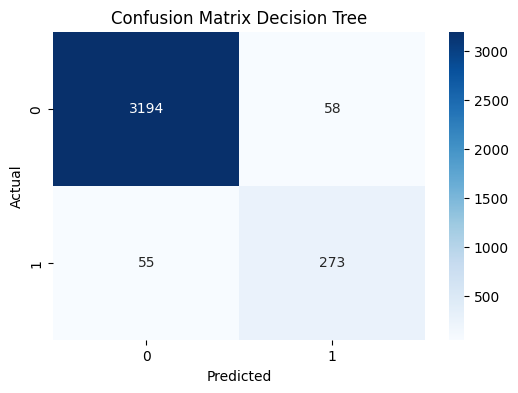

In [19]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Decision Tree")
plt.show()

CELL 10 — Visualisasi Pohon Keputusan

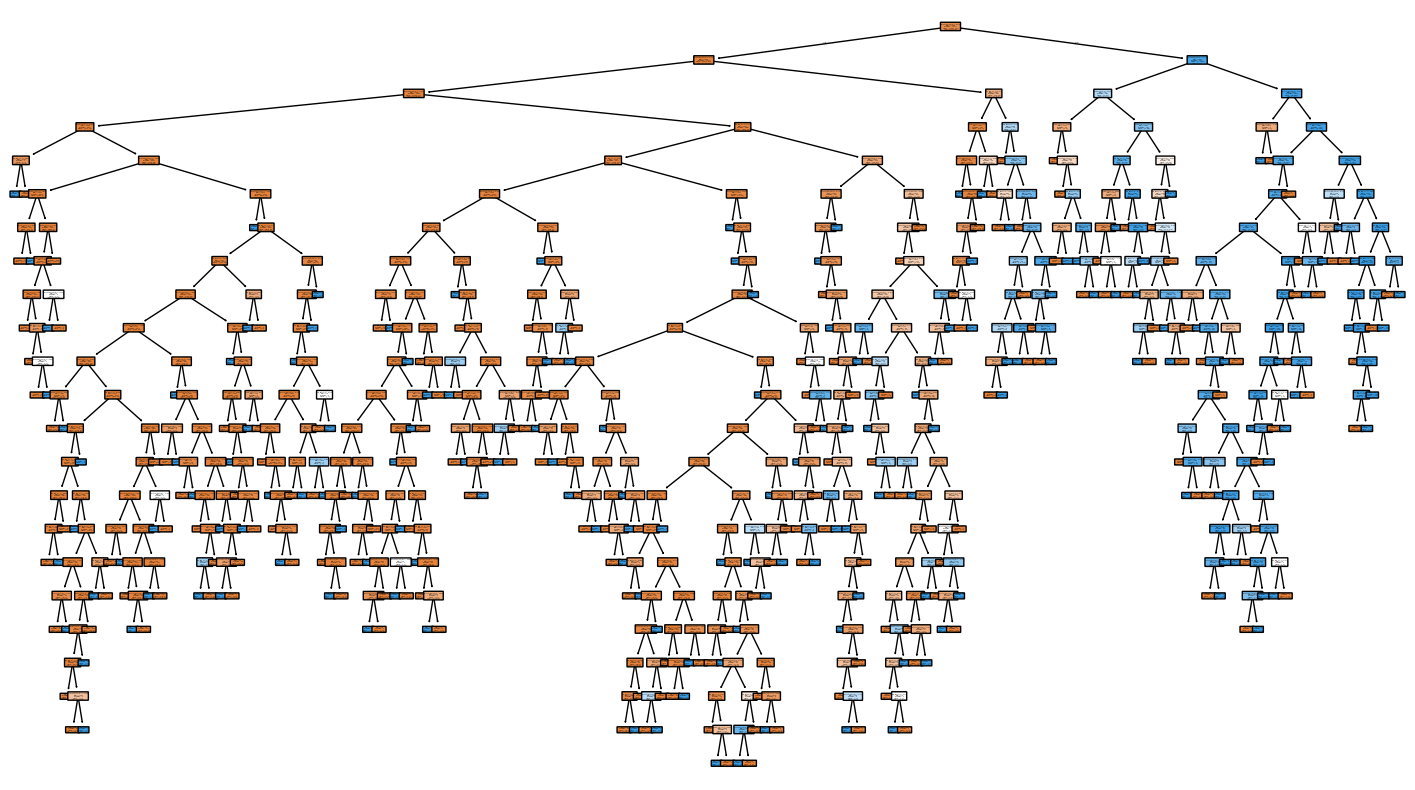

In [20]:
plt.figure(figsize=(18,10))
plot_tree(dt, 
          feature_names=X.columns,
          class_names=["Non-Pulsar", "Pulsar"],
          filled=True,
          rounded=True)
plt.show()

Decision Tree versi pendek

In [23]:
dt_small = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

dt_small.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Visualisasi Pohon Rapi (max_depth=3) (biar singkat ajaa)

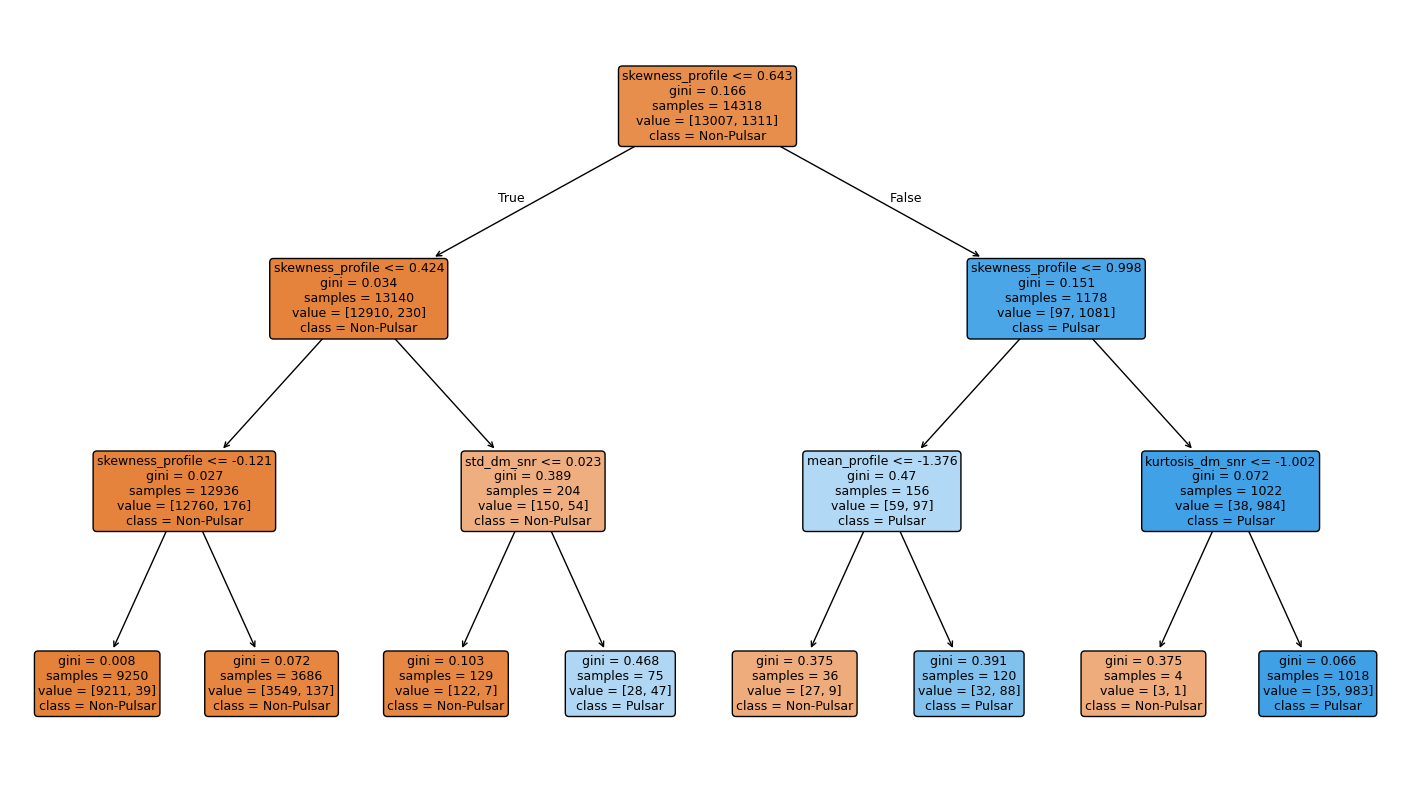

In [24]:
plt.figure(figsize=(18,10))
plot_tree(dt_small,
          feature_names=X.columns,
          class_names=["Non-Pulsar", "Pulsar"],
          filled=True,
          rounded=True,
          fontsize=9)
plt.show() 